In [1]:
import os
import shap
import torch
import random
import numpy as np
import pandas as pd
import torch.nn as nn
from torch import optim
import matplotlib.pyplot as plt
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from mlp import*

/home/rachel/miniforge3/envs/mm-vae/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# initialize parameters 
full_input_path = '/home/rachel/Desktop/drosophila_sleep_analysis/agg_input_data_subset2/agg_ld8_1000epochs_v3/latent_variables_epoch1000.csv'
output_path = '/home/rachel/Desktop/drosophila_sleep_analysis/agg_input_data_subset2/mlp_ld8_agg_v3'
os.makedirs(output_path, exist_ok=True)
input_type = 'latent' # 'raw' or 'latent'

# c-gmvae model parameters 
latent_dim = 8

# mlp model parameters 
hidden_dim1 = 4
hidden_dim2 = 8

# training parameters 
learning_rate = 0.001
epochs = 100
batch_size = 64
test_split = 0.2
random_seed = 10

In [3]:
%%writefile ~/Desktop/drosophila_sleep_analysis/agg_input_data_subset2/mlp_ld8_agg_v3/config.txt
# initialize parameters 
full_input_path = '/home/rachel/Desktop/drosophila_sleep_analysis/agg_input_data_subset2/agg_ld8_1000epochs_v3/latent_variables_epoch1000.csv'
output_path = '/home/rachel/Desktop/drosophila_sleep_analysis/agg_input_data_subset2/mlp_ld8_agg_v3'
os.makedirs(output_path, exist_ok=True)
input_type = 'latent' # 'raw' or 'latent'

# c-gmvae model parameters 
latent_dim = 8

# mlp model parameters 
hidden_dim1 = 4
hidden_dim2 = 8

# training parameters 
learning_rate = 0.001
epochs = 100
batch_size = 64
test_split = 0.2
random_seed = 10

Overwriting /home/rachel/Desktop/drosophila_sleep_analysis/agg_input_data_subset2/mlp_ld8_agg_v3/config.txt


In [4]:
# set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# set seed
np.random.seed = random_seed
random.seed(random_seed)
torch.manual_seed(random_seed)
torch.cuda.manual_seed(random_seed)

In [5]:
# for inputting latent data
class DataBuilder(Dataset):
    def __init__(self, data, latent_dim):
        self.x, self.genotype, self.AD_label = load_latent_data(data, latent_dim)
        self.len = self.x.shape[0]
    def __getitem__(self, index):
        return self.x[index], self.genotype[index], self.AD_label[index]
    def __len__(self):
        return self.len

def load_latent_data(df, latent_dim): 
    x = df.iloc[:, :latent_dim].values.astype('float32')
    #fly_id = df['flyID'].tolist()
    genotype = df['genotype'].tolist()
    labels = df['ad_label'].values.astype('int')
    return x, genotype, labels

# for inputting raw data to MLP
class DataBuilder_RawData(Dataset):
    def __init__(self, data):
        self.x, self.genotype, self.AD_label = load_raw_data(data)
        self.len = self.x.shape[0]
    def __getitem__(self, index):
        return self.x[index], self.genotype[index], self.AD_label[index]
    def __len__(self):
        return self.len

def load_raw_data(df):
    x = df.iloc[:, 8:].values.astype('float32')
    genotype = df['Genotype (F>M)'].tolist()
    labels = df['AD_label'] = np.where(
        (df['Genotype (F>M)'].str.contains('attp2', case=False, na=False)) | (df['Genotype (F>M)'].str.contains('attp4', case=False, na=False)), 
        0, 
        1
    )
    return x, genotype, labels

In [6]:
full_input = pd.read_csv(full_input_path)
train_df, test_df = train_test_split(full_input, test_size=test_split, random_state=random_seed)
scaler = StandardScaler()
if input_type == 'latent':
    train_df.iloc[:, :latent_dim] = scaler.fit_transform(train_df.iloc[:, :latent_dim])
    test_df.iloc[:, :latent_dim] = scaler.fit_transform(test_df.iloc[:, :latent_dim])
    train_dataset = DataBuilder(train_df, latent_dim)
    test_dataset = DataBuilder(test_df, latent_dim)
else:
    train_df.iloc[:, 8:] = scaler.fit_transform(train_df.iloc[:, 8:])
    test_df.iloc[:, 8:] = scaler.fit_transform(test_df.iloc[:, 8:])
    train_dataset = DataBuilder_RawData(train_df)
    test_dataset = DataBuilder_RawData(test_df)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

In [7]:
# initialize model
model = mlp(latent_dim, hidden_dim1, hidden_dim2).to(device)
#criterion = nn.BCELoss() # or could try nn.BCEWithLogitsLoss()
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [8]:
def train(epoch, model, train_loader, device, optimizer):
    model.train()
    train_loss = 0
    all_outputs = []
    all_labels = []
    all_probs = []
    #for batch_idx, (data, fly_id, genotype, labels) in enumerate(train_loader):
    for batch_idx, (data, genotype, labels) in enumerate(train_loader):
        data = data.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        logits = model(data)
        labels = labels.unsqueeze(1).float()
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        pred = (logits > 0).float()
        all_outputs.append(pred.detach().cpu())
        all_labels.append(labels.cpu())
        all_probs.append(logits.detach().cpu())

    all_outputs = torch.cat(all_outputs)
    all_labels = torch.cat(all_labels)
    all_probs = torch.cat(all_probs)
    
    print(f'Epoch {epoch} Training loss: {train_loss / len(train_loader)}')

    return train_loss / len(train_loader), all_outputs, all_labels, all_probs

def test(epoch, model, test_loader, device, output_path):
    model.eval()
    test_loss = 0
    all_outputs = []
    all_labels = []
    with torch.no_grad():
        #for batch_idx, (data, fly_id, genotype, labels) in enumerate(test_loader):
        for batch_idx, (data, genotype, labels) in enumerate(test_loader):
            data = data.to(device)
            labels = labels.to(device)
            logits = model(data)
            labels = labels.unsqueeze(1).float()
            loss = criterion(logits, labels)
            test_loss += loss.item()
            pred = (logits > 0).float()
            all_outputs.append(pred.cpu())
            all_labels.append(labels.cpu())

    all_outputs = torch.cat(all_outputs)
    all_labels = torch.cat(all_labels)
    
    print(f'Epoch {epoch} Testing loss: {test_loss / len(test_loader)}')

    test_acc = (all_outputs == all_labels).sum().item() / len(all_labels)

    return test_loss / len(test_loader), test_acc, all_outputs, all_labels

In [9]:
total_train_loss = []
total_test_loss = []
total_test_acc = []
test_epochs = []

for epoch in range(1, epochs + 1):
    train_loss, train_outputs, train_labels, train_probs = train(epoch, model, train_loader, device, optimizer)
    total_train_loss.append(train_loss)
    step = epochs / 10
    if epoch in torch.arange(step, epochs+1, step=step):
        test_loss, test_acc, outputs, labels = test(epoch, model, test_loader, device, output_path)
        total_test_loss.append(test_loss)
        total_test_acc.append(test_acc)
        test_epochs.append(epoch)

Epoch 1 Training loss: 0.6098256882499246
Epoch 2 Training loss: 0.5662920860683217
Epoch 3 Training loss: 0.5267996016670676
Epoch 4 Training loss: 0.4919307337087743
Epoch 5 Training loss: 0.4602052604450899
Epoch 6 Training loss: 0.4297565747709835
Epoch 7 Training loss: 0.4005877270418055
Epoch 8 Training loss: 0.3715050343204947
Epoch 9 Training loss: 0.34489957900608287
Epoch 10 Training loss: 0.31913671072791605
Epoch 10 Testing loss: 0.2966488003730774
Epoch 11 Training loss: 0.29372506106601043
Epoch 12 Training loss: 0.27242639573181376
Epoch 13 Training loss: 0.25204920505776124
Epoch 14 Training loss: 0.23331987682510824
Epoch 15 Training loss: 0.21538248395218568
Epoch 16 Training loss: 0.20103564595474915
Epoch 17 Training loss: 0.18763616155175603
Epoch 18 Training loss: 0.17500092439791737
Epoch 19 Training loss: 0.16485997596207788
Epoch 20 Training loss: 0.15523149029296987
Epoch 20 Testing loss: 0.1448505327105522
Epoch 21 Training loss: 0.14690315328976689
Epoch 22 

   Epoch  Test accuracy
0     10       0.988806
1     20       0.985075
2     30       0.988806
3     40       0.992537
4     50       0.996269
5     60       1.000000
6     70       1.000000
7     80       0.996269
8     90       0.996269
9    100       0.996269


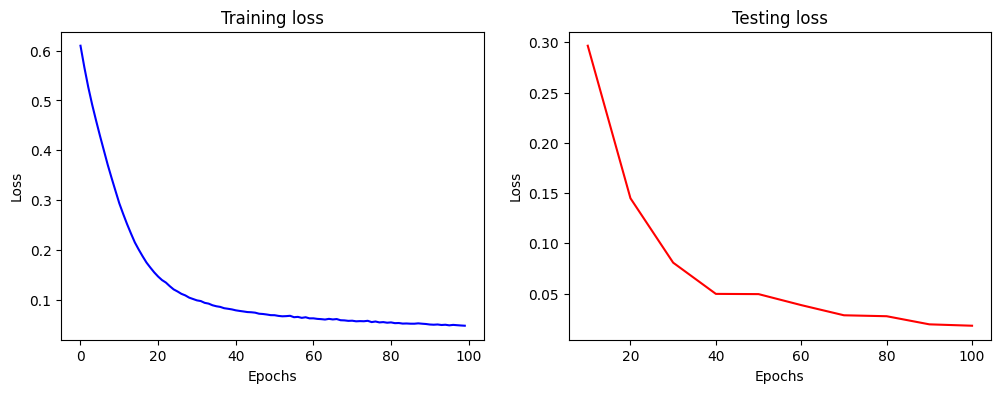

In [10]:
test_acc_df = pd.DataFrame({
    'Epoch': test_epochs,
    'Test accuracy': total_test_acc
})
print(test_acc_df)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))
axes[0].plot(total_train_loss, color='blue')
axes[0].set_title('Training loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[1].plot(test_epochs, total_test_loss, color='red', label='Testing loss')
axes[1].set_title('Testing loss')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
test_acc_df.to_csv(os.path.join(output_path, 'test_acc.csv'), index=False)
plt.savefig(os.path.join(output_path, 'train_test_loss.png'))

In [11]:
total_test_acc

[0.9888059701492538,
 0.9850746268656716,
 0.9888059701492538,
 0.9925373134328358,
 0.996268656716418,
 1.0,
 1.0,
 0.996268656716418,
 0.996268656716418,
 0.996268656716418]

Plot training results

In [12]:
train_labels.shape

torch.Size([1072, 1])

In [13]:
train_probs.shape

torch.Size([1072, 1])

Text(0.5, 1.0, 'Actual labels')

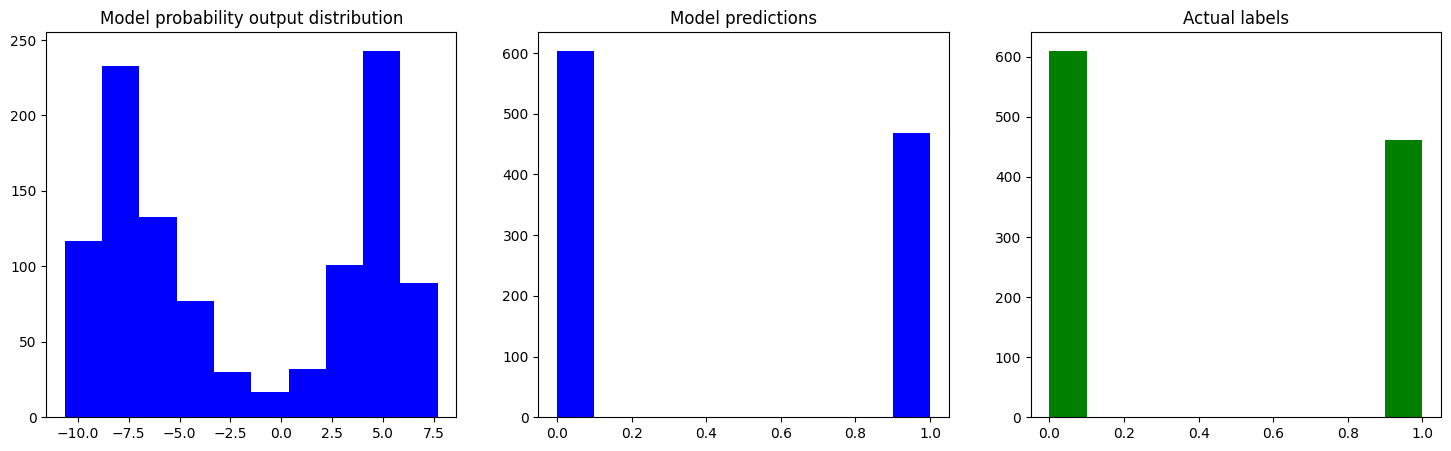

In [14]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))
axes[0].hist(train_probs.numpy(), color='blue')
axes[0].set_title('Model probability output distribution')
axes[1].hist(train_outputs.numpy(), color='blue')
axes[1].set_title('Model predictions')
axes[2].hist(train_labels.numpy(), color='green')
axes[2].set_title('Actual labels')

In [15]:
correct = (train_outputs == train_labels).sum().item()
accuracy = correct / len(train_labels)
accuracy

0.9813432835820896

Adding feature analysis (SHAP)

In [16]:
train_df.iloc[:100, 8:-1]

,genotype,Sex
782,Swedish>attp2,F
414,alrm>attp2,F
997,elavQF>QAb42,M
907,attp2>Ab42,M
329,attp2>nsybG4,F
...,...,...
962,SwedArc>attp2,vF
616,London>attp40,M
51,attp2>Ab42-Arc,F
1266,nsyb>55672,M


In [17]:
def predict(data):
    model.eval()
    data = torch.FloatTensor(data).to(device)
    with torch.no_grad():
        logits = model(data)
        probs = torch.sigmoid(logits)
    return probs.cpu().numpy()

100%|██████████| 100/100 [00:00<00:00, 235.98it/s]


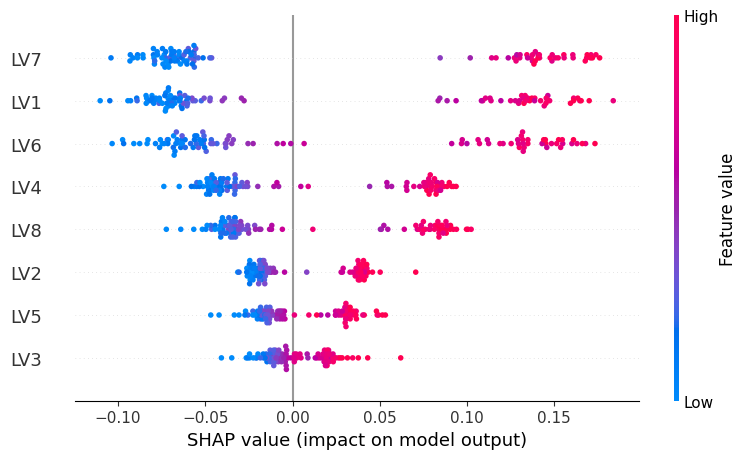

In [18]:
# do SHAP analysis 
if input_type == 'latent':
    background = train_df.iloc[:100, :latent_dim]
    test = test_df.iloc[:100, :latent_dim]
else: 
    background = train_df.iloc[:100, 8:-1]
    test = test_df.iloc[:20, 8:-1]

explainer = shap.KernelExplainer(predict, background)
shap_values = explainer.shap_values(test, n_samples='auto')
shap.summary_plot(shap_values.squeeze(), test, show=False)
plt.savefig(os.path.join(output_path, 'shap_analysis.png'))

In [19]:
# calculate weights for each of the shapley values 
feature_weights = np.mean(np.abs(shap_values.squeeze()), axis=0)
shap_importance = pd.DataFrame({
    'Latent Feature': test.columns, 
    'Feature Weight': feature_weights.tolist()
})
shap_importance.to_csv(os.path.join(output_path, 'shap_importance.csv'), index=False)